### Load System Libraries

In [59]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "useful-python-scripts-eda")))
from data_profiler import DataProfiler
from distribution_analyzer import DistributionAnalyzer
from correlation_explorer import CorrelationExplorer
from outlier_suite import OutlierSuite
from missing_data_analyzer import MissingDataAnalyzer

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from relbench.datasets import get_dataset

### Load Datasets

In [38]:
db = get_dataset("rel-hm", download=True).get_db(upto_test_timestamp=False)

In [39]:
articles_df = db.table_dict["article"].df
customers_df = db.table_dict["customer"].df
transactions_df = db.table_dict["transactions"].df

### Comprehensive Data Profiler

In [40]:
df = transactions_df.copy()

In [41]:
# Create profiler.
profiler = DataProfiler(df, high_cardinality_threshold=0.5)

In [42]:
# Print summary to console.
profiler.print_summary()

Generating data profile...
Profile generation complete!

DATASET OVERVIEW
Total Rows: 15453651
Total Columns: 5
Total Missing Cells: 0
Total Memory Mb: 618.99
Duplicate Rows: 1417034
Duplicate Percentage: 9.17
Numeric Columns: 4
Categorical Columns: 0
Datetime Columns: 1
Boolean Columns: 0

NUMERIC COLUMNS SUMMARY
            name  null_percentage        mean         std  min_value    max_value  skewness
     customer_id              0.0 685015.7794 396099.9888        0.0 1371979.0000    0.0023
      article_id              0.0  67969.7502  28034.2610        0.0  105539.0000   -0.9766
           price              0.0      0.0284      0.0192        0.0       0.5068    3.0931
sales_channel_id              0.0      1.7175      0.4502        1.0       2.0000   -0.9664

CATEGORICAL COLUMNS SUMMARY
No categorical columns found

DATA QUALITY ISSUES
No major issues detected



In [43]:
# Get detailed report.
profiler_report = profiler.generate_full_profile()
print(profiler_report["overview"])
print(profiler_report["numeric_profiles"])
print(profiler_report["categorical_profiles"])
print(profiler_report["data_quality_issues"])

Generating data profile...
Profile generation complete!
{'total_rows': 15453651, 'total_columns': 5, 'total_missing_cells': np.int64(0), 'total_memory_mb': np.float64(618.99), 'duplicate_rows': np.int64(1417034), 'duplicate_percentage': np.float64(9.17), 'numeric_columns': 4, 'categorical_columns': 0, 'datetime_columns': 1, 'boolean_columns': 0}
               name    dtype  non_null_count  null_count  null_percentage  \
0       customer_id    Int64        15453651           0              0.0   
1        article_id    Int64        15453651           0              0.0   
2             price  float64        15453651           0              0.0   
3  sales_channel_id    int64        15453651           0              0.0   
4       customer_id    Int64        15453651           0              0.0   
5        article_id    Int64        15453651           0              0.0   
6             price  float64        15453651           0              0.0   
7  sales_channel_id    int64        

### Analyzing And Visualizing Distributions

In [44]:
analyzer = DistributionAnalyzer(df)

In [45]:
# Generate distribution report
analyzer_report = analyzer.generate_distribution_report()
print(analyzer_report)

             column     count         mean       median          mode  \
0       customer_id  15453651  685015.7794  684713.0000  1.018839e+06   
1        article_id  15453651   67969.7502   76434.0000  5.389200e+04   
2             price  15453651       0.0284       0.0254  3.390000e-02   
3  sales_channel_id  15453651       1.7175       2.0000  2.000000e+00   

           std  skewness  kurtosis  is_normal normality_p_value  \
0  396099.9888    0.0023   -1.1980      False              None   
1   28034.2610   -0.9766   -0.0434      False              None   
2       0.0192    3.0931   24.9928      False              None   
3       0.4502   -0.9664   -1.0661      False              None   

            distribution_type  outlier_count  outlier_percentage  
0  Platykurtic (Light-tailed)              0                0.00  
1     Approximately symmetric         307110                1.99  
2     Right-skewed (Positive)         978107                6.33  
3     Approximately symmetric 

In [46]:
# Identify highly skewed columns
skewed = analyzer_report[abs(analyzer_report['skewness']) > 2]
print(f"Highly skewed columns: {skewed['column'].tolist()}")

Highly skewed columns: ['price']


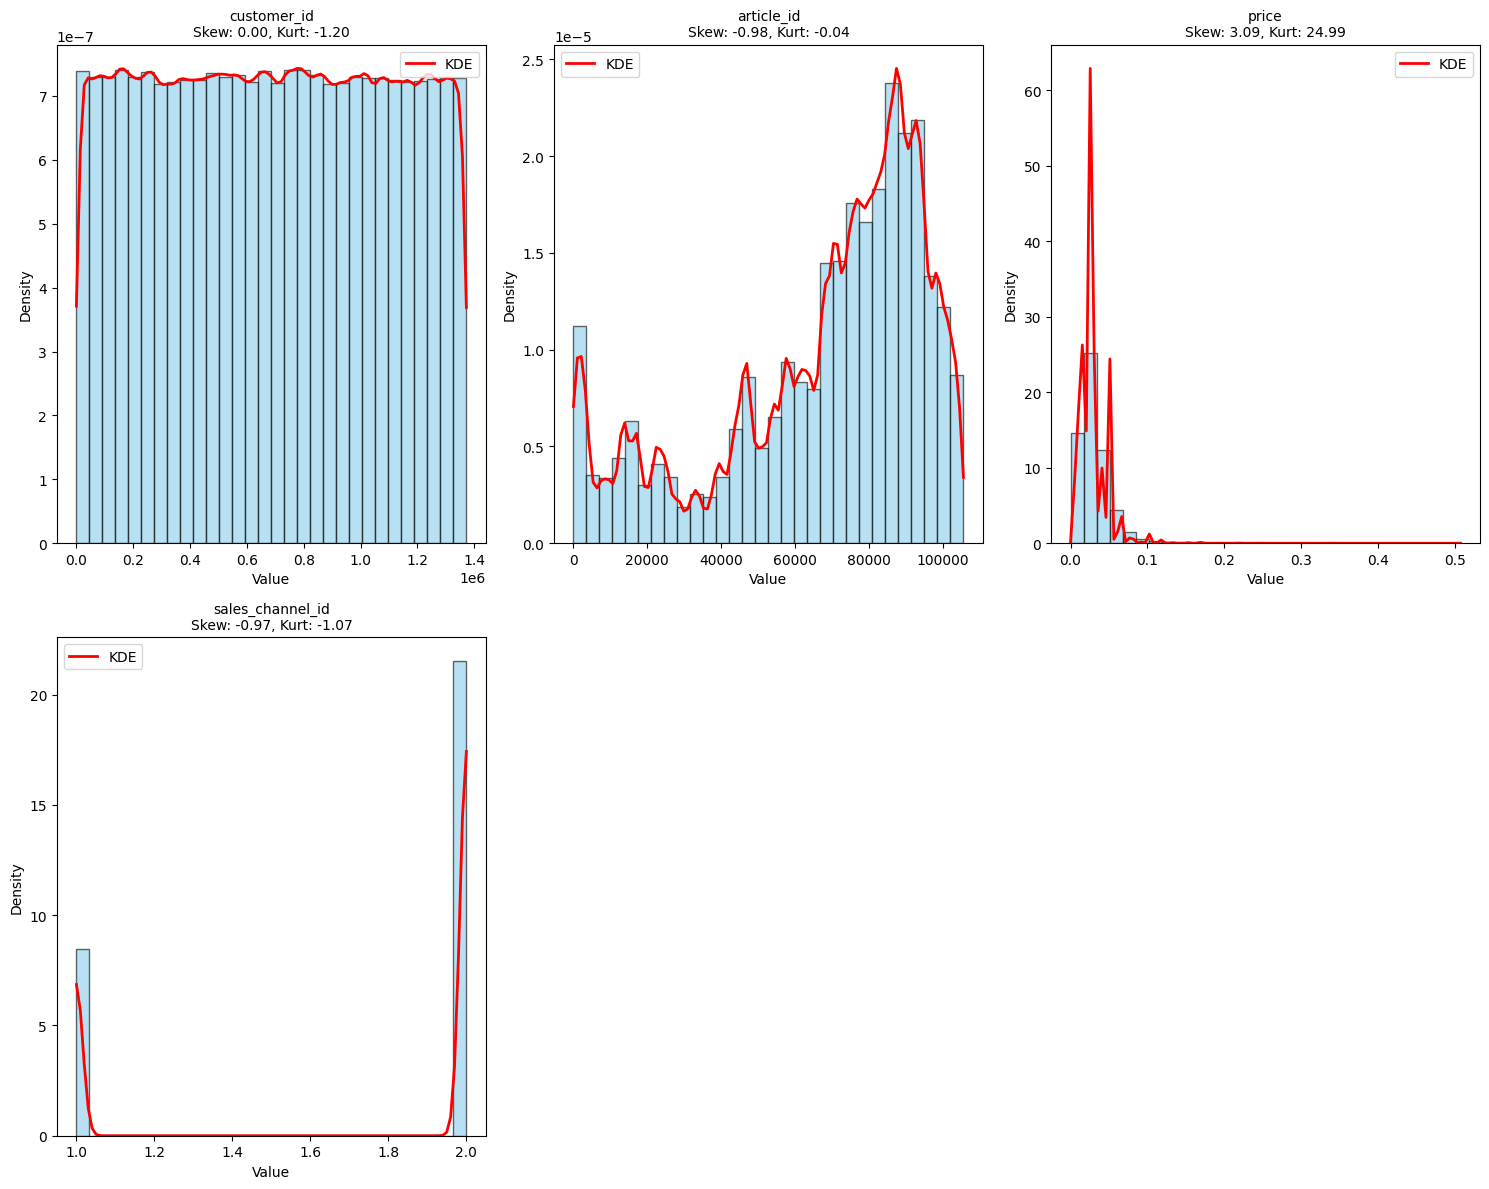

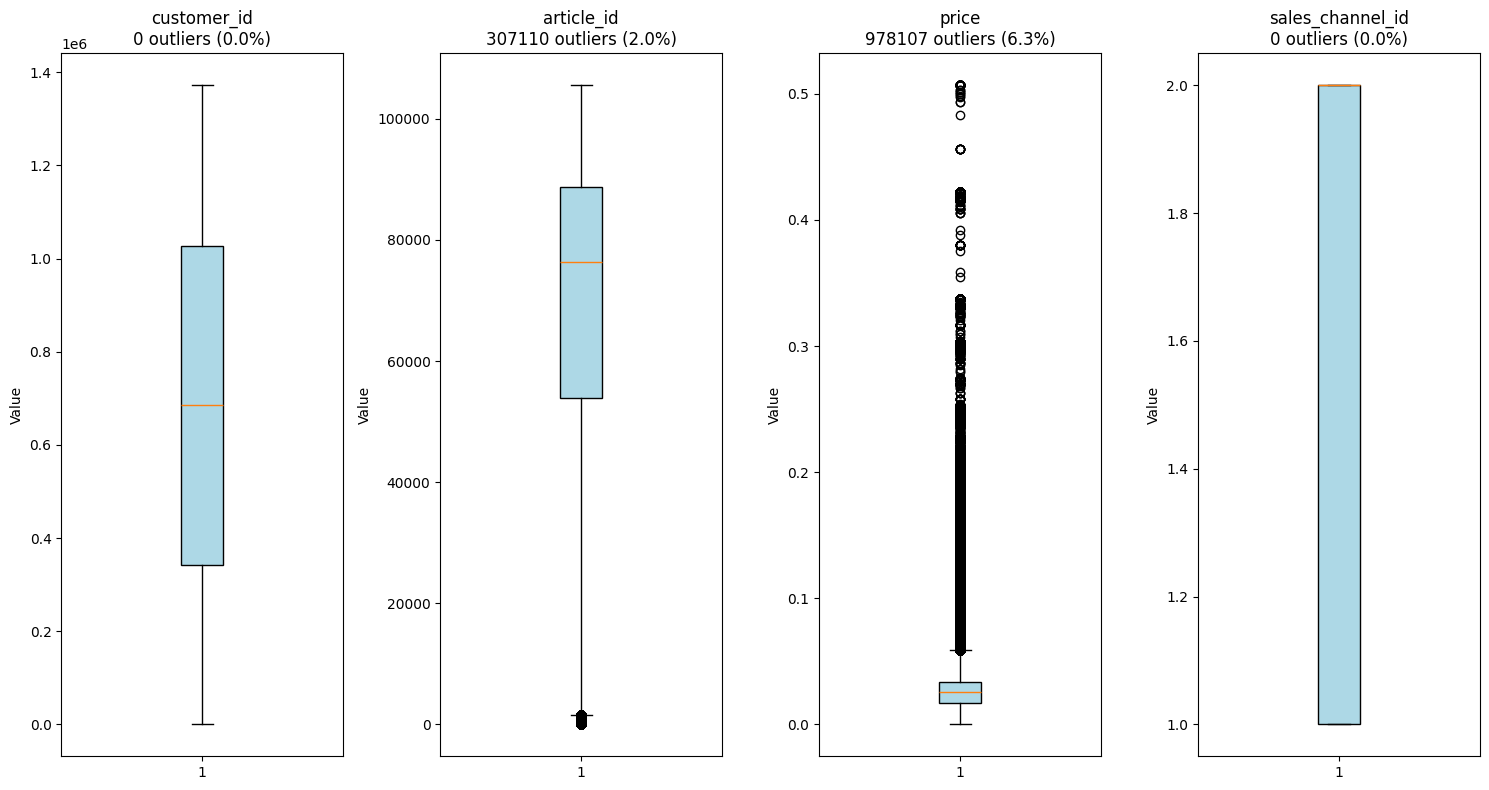

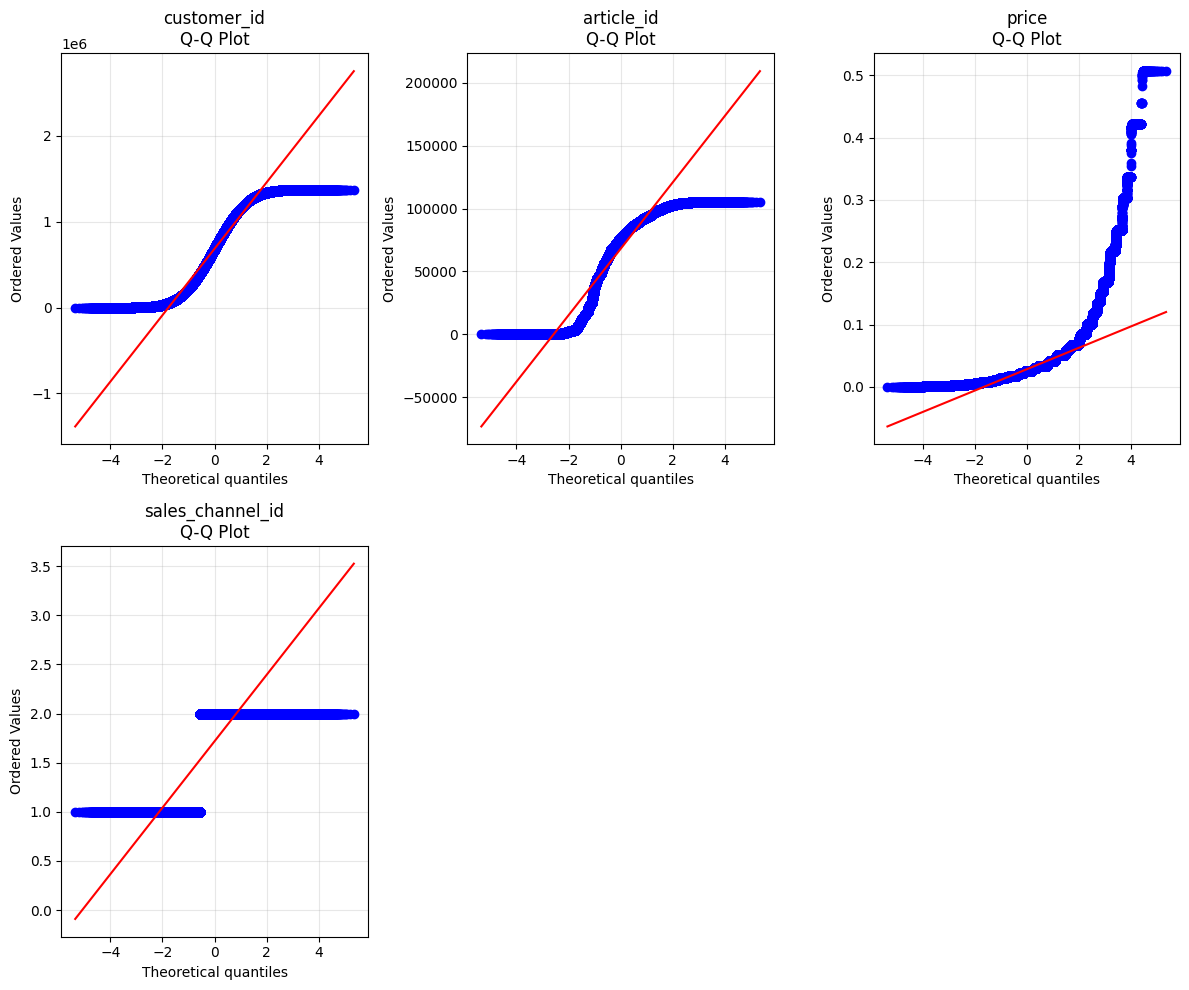

No categorical columns to plot


In [47]:
# Visualize distributions
analyzer.plot_numeric_distributions(max_cols=10)
analyzer.plot_boxplots()
analyzer.plot_qq_plots()
analyzer.plot_categorical_distributions()

### Correlation and Relationship Explorer

In [48]:
explorer = CorrelationExplorer(df)

In [49]:
# Find high correlations
high_corr = explorer.find_high_correlations(threshold=0.7, method='pearson')
print(high_corr)

Empty DataFrame
Columns: []
Index: []


In [50]:
# Check for multicollinearity
vif = explorer.calculate_vif()
problematic = vif[vif['vif'] > 10]
print(f"Features with high multicollinearity:\n{problematic}")

Features with high multicollinearity:
Empty DataFrame
Columns: [feature, vif, r_squared, multicollinearity]
Index: []


In [51]:
# Mutual information with target
if 'target' in df.columns:
    mi_scores = explorer.mutual_information_analysis('target')
    print(f"Top features:\n{mi_scores.head(10)}")

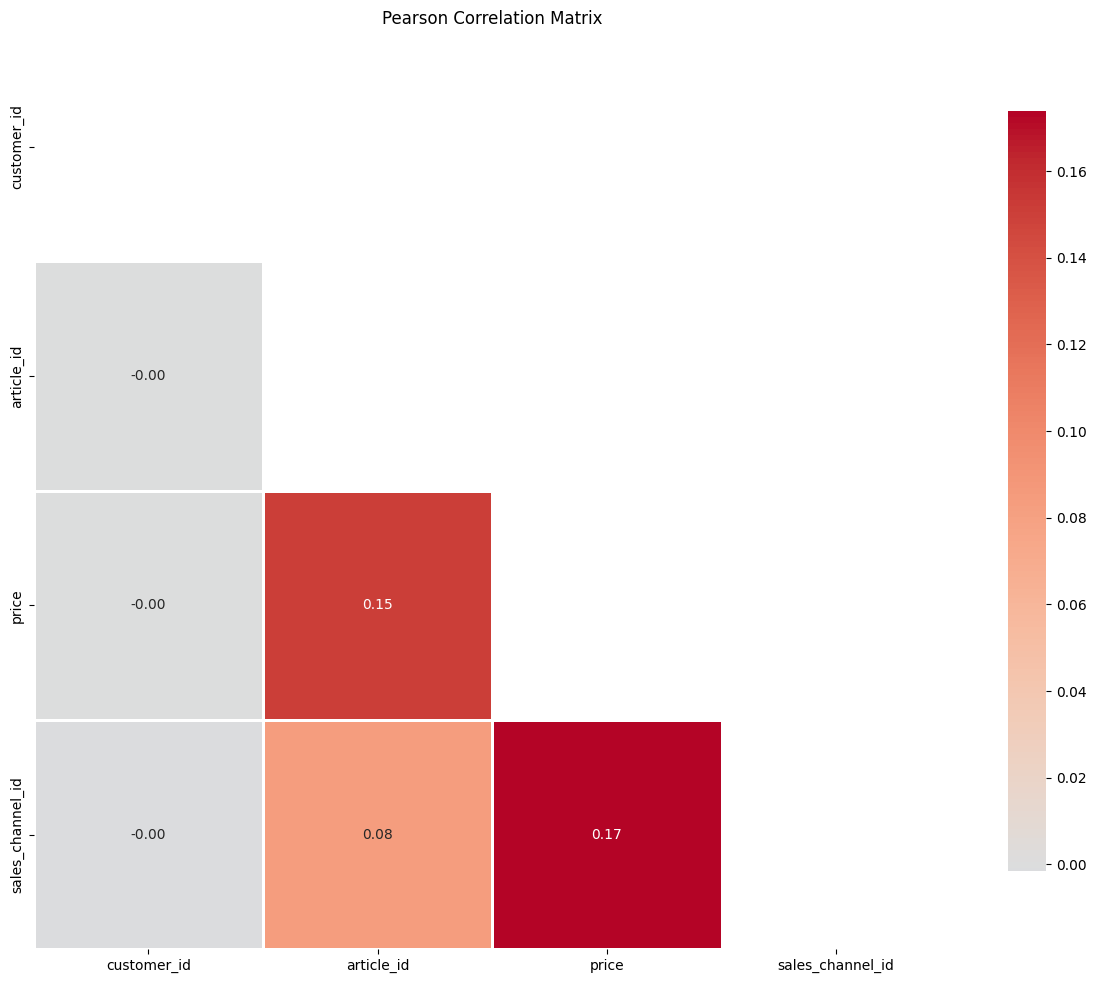

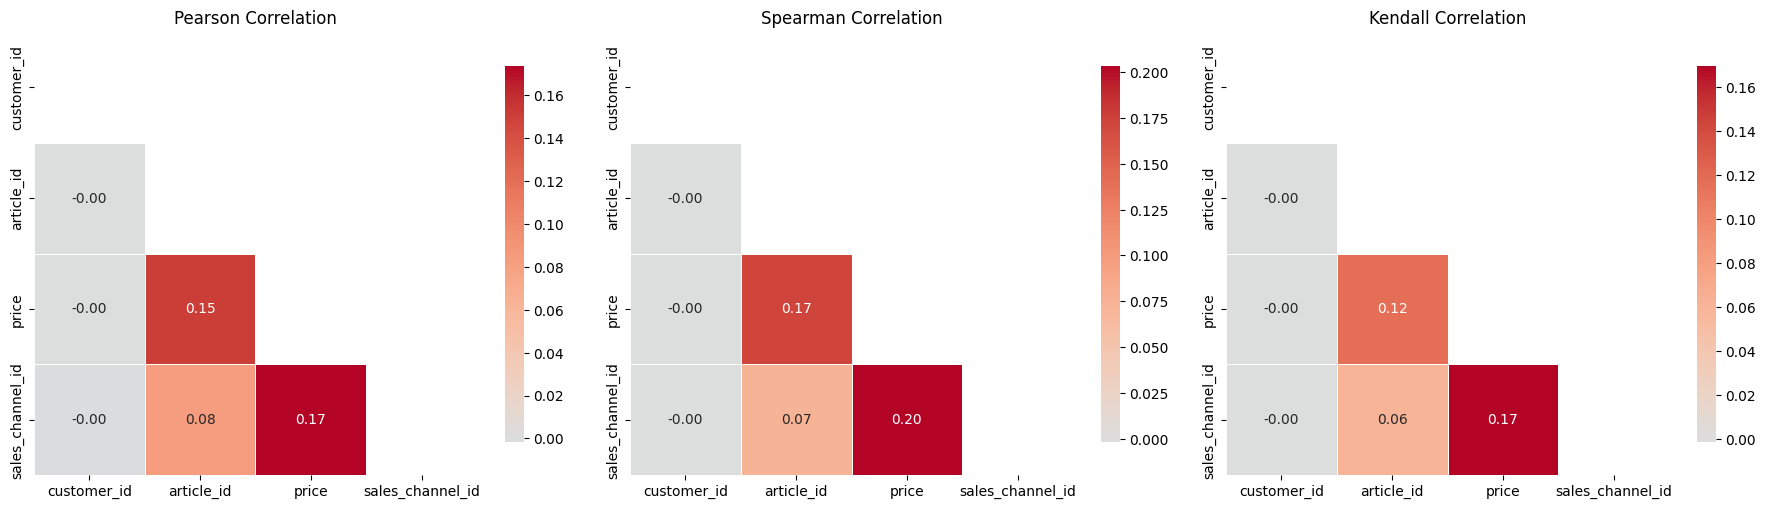

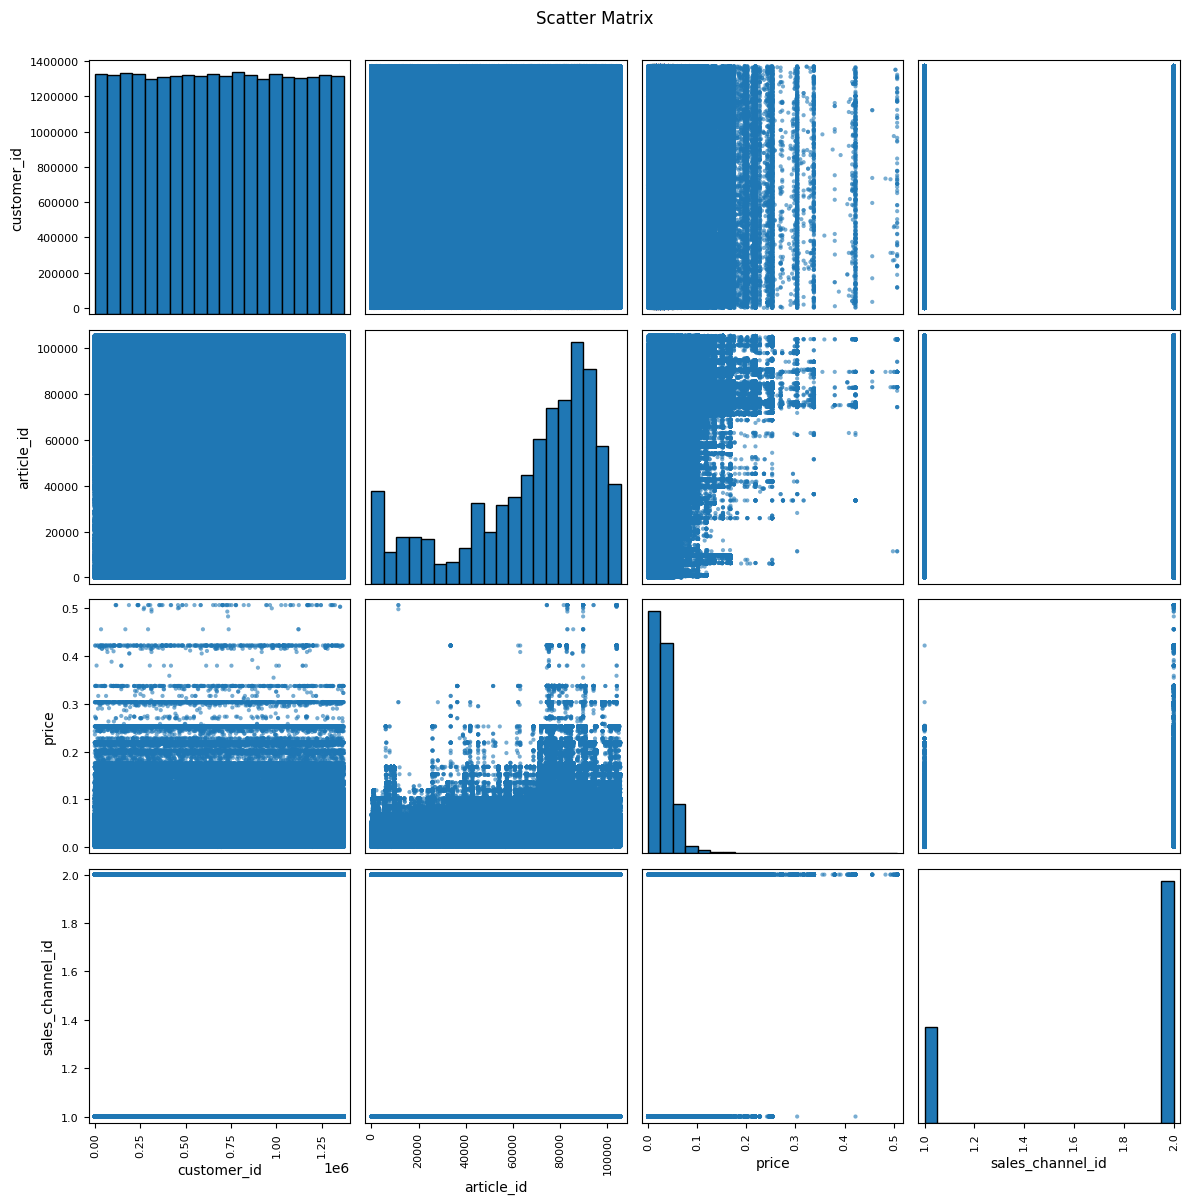

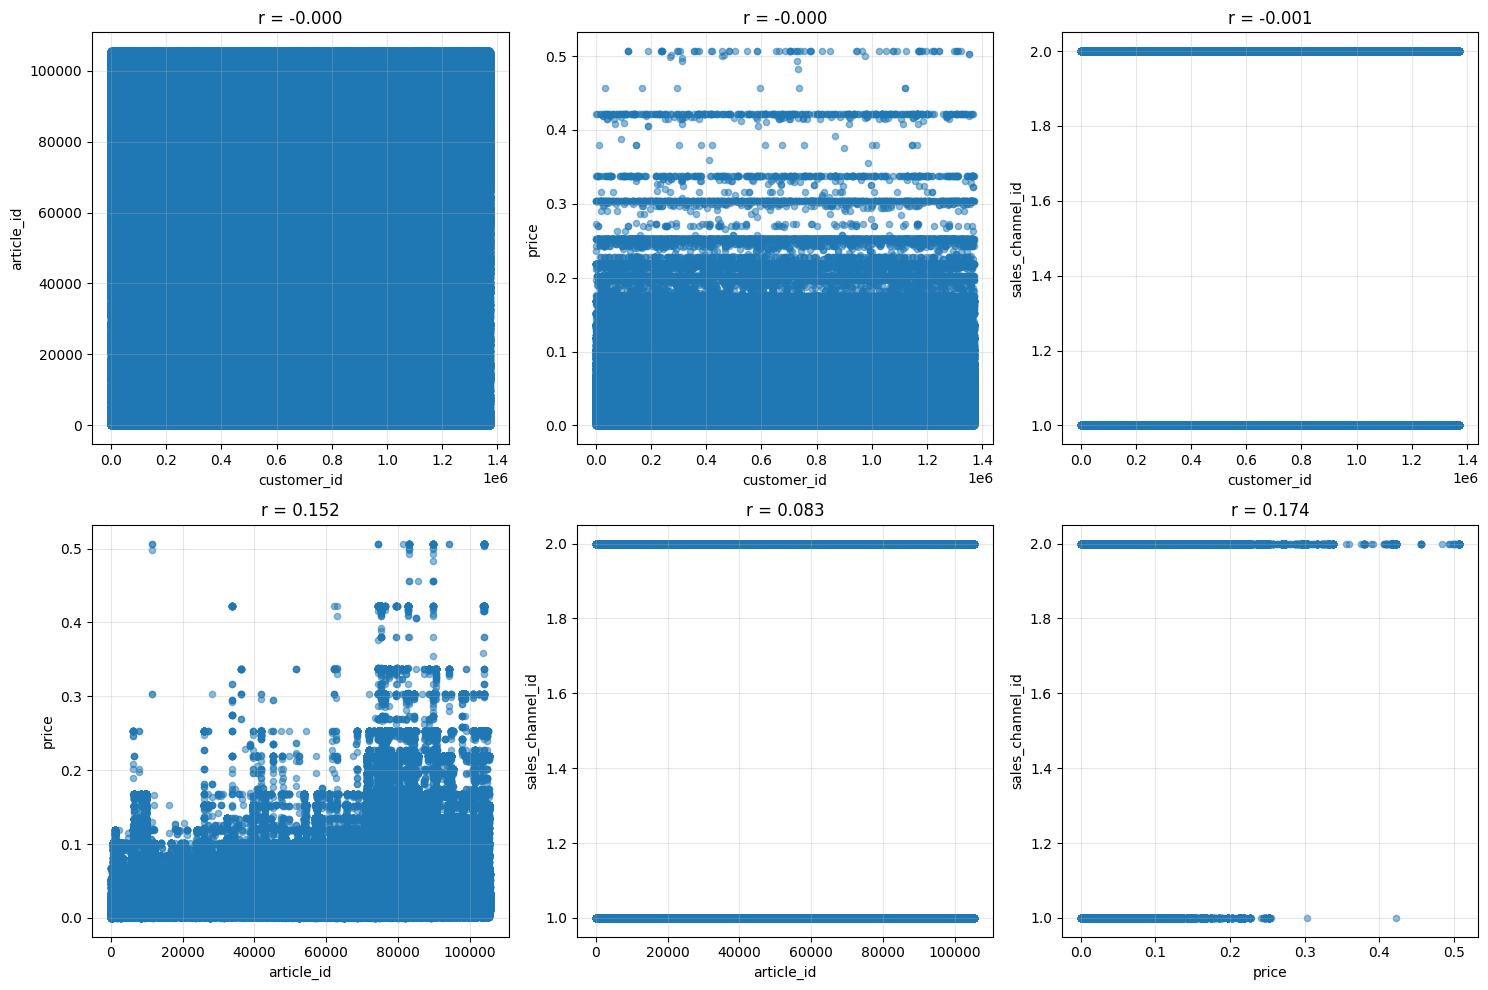

In [52]:
# Visualize
explorer.plot_correlation_heatmap(method='pearson')
explorer.plot_correlation_comparison()
explorer.plot_scatter_matrix(max_cols=5)
explorer.plot_top_correlations(n_pairs=10)

### Outlier Detection and Analysis Suite

In [53]:
suite = OutlierSuite(df)

In [54]:
# Compare methods across all columns
summary = suite.compare_methods_all_columns()
print(summary)

             column  total_outliers_iqr  total_outliers_zscore  \
0       customer_id                   0                      0   
1        article_id              307110                      0   
2             price              978107                 180075   
3  sales_channel_id                   0                      0   

   total_outliers_modified_zscore  consensus_outliers  percentage_consensus  
0                               0                   0                  0.00  
1                               0                   0                  0.00  
2                          365270              365270                  2.36  
3                               0                   0                  0.00  


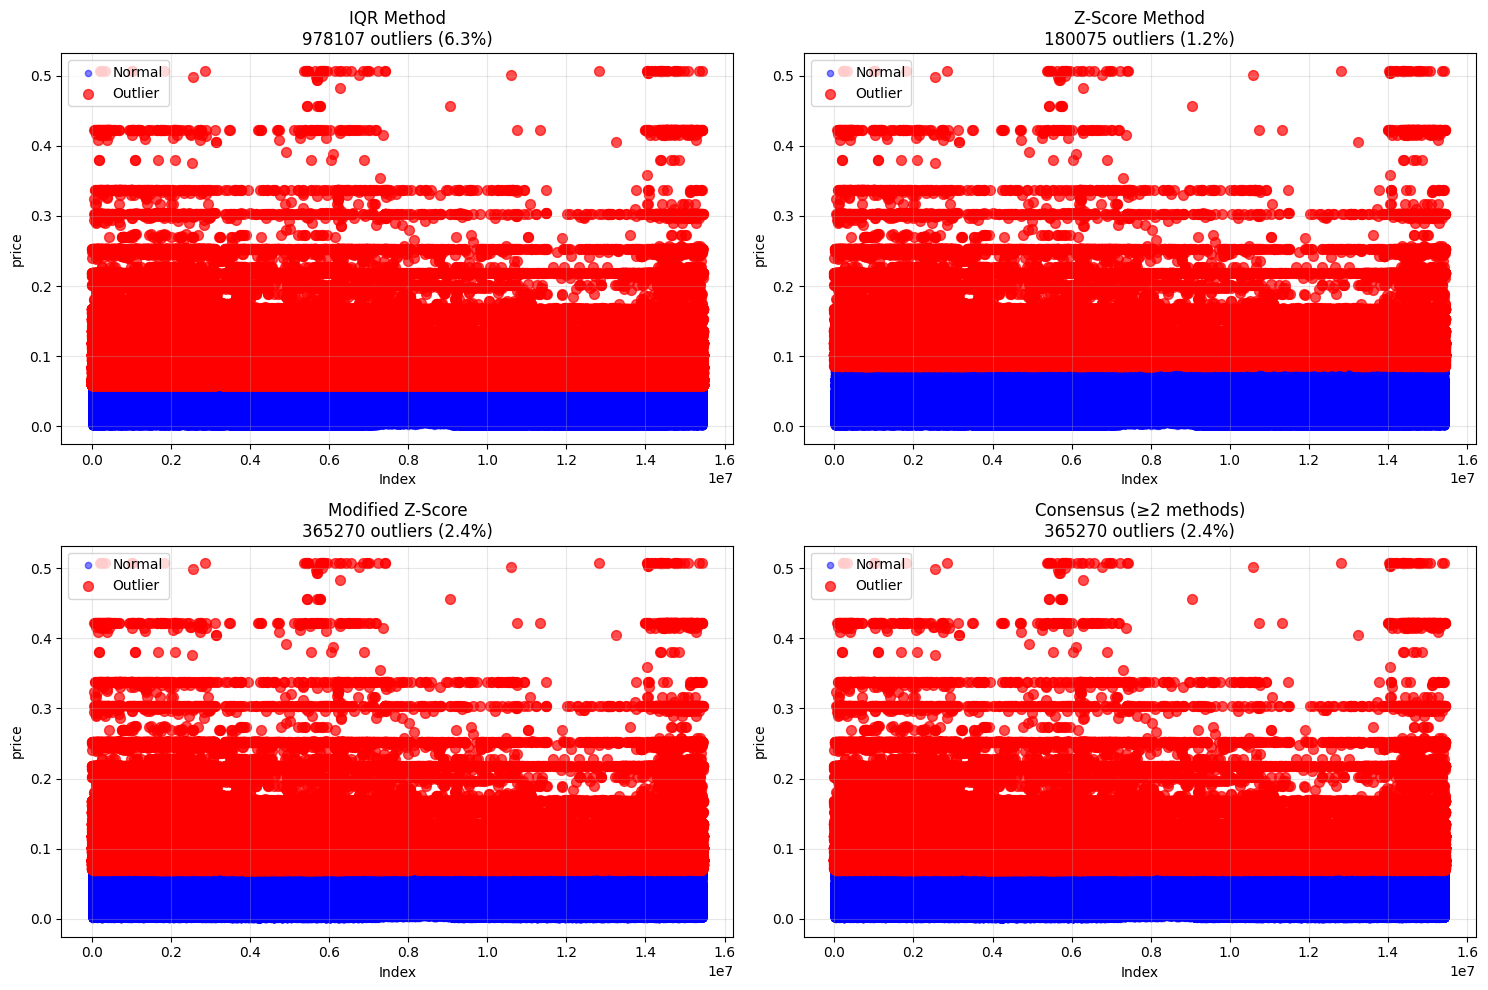

In [55]:
# Analyze specific column
col = "price"
suite.plot_outlier_comparison(col)

Found 1545365 multivariate outliers


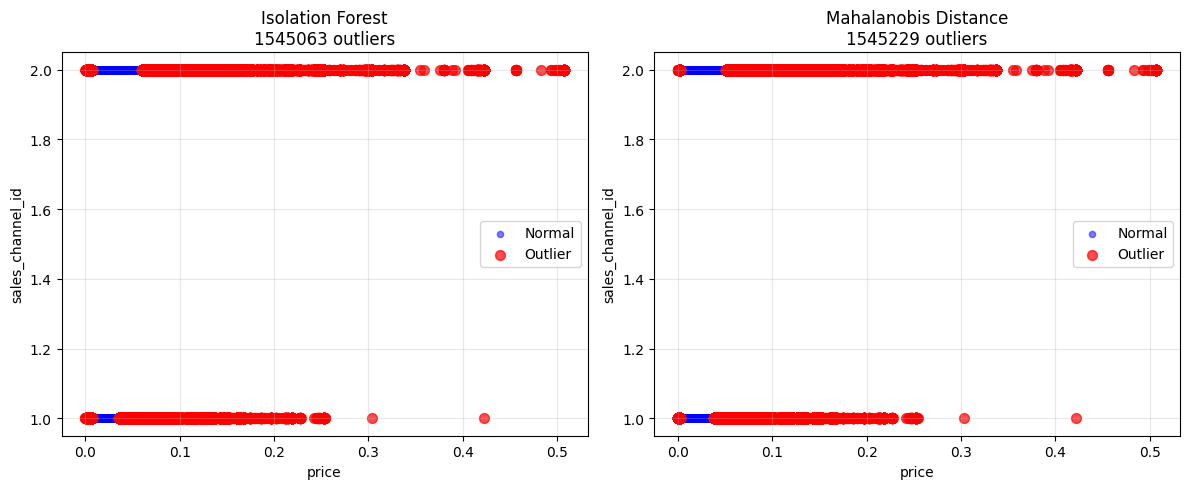

In [57]:
# Detect multivariate outliers
iso_outliers = suite.detect_isolation_forest_outliers(contamination=0.1)
print(f"Found {iso_outliers.sum()} multivariate outliers")

feature1 = "price"
feature2 = "sales_channel_id"
suite.plot_multivariate_outliers([feature1, feature2])

In [58]:
# Analyze outlier impact
col = "price"
impact = suite.analyze_outlier_impact(col)
print(impact)

{'column': 'price', 'mean_with_outliers': np.float64(0.0284), 'mean_without_outliers': np.float64(0.0266), 'mean_difference': np.float64(0.0018), 'median_with_outliers': np.float64(0.0254), 'median_without_outliers': np.float64(0.0254), 'std_with_outliers': np.float64(0.0192), 'std_without_outliers': np.float64(0.0143)}


### Missing Data Pattern Analyzer

In [60]:
analyzer = MissingDataAnalyzer(df)

In [61]:
# Generate full report
report = analyzer.generate_full_report()

print("Missing Value Summary:")
print(report['summary'])

print("\nMissingness Patterns (co-occurrence):")
print(report['patterns'])

print("\nMissingness Classifications:")
print(report['classifications'])

print("\nImputation Recommendations:")
print(report['recommendations'])

Missing Value Summary:
Empty DataFrame
Columns: []
Index: []

Missingness Patterns (co-occurrence):
Empty DataFrame
Columns: []
Index: []

Missingness Classifications:
Empty DataFrame
Columns: []
Index: []

Imputation Recommendations:
Empty DataFrame
Columns: []
Index: []


In [62]:
# Visualize patterns
analyzer.plot_missing_bar()
analyzer.plot_missing_heatmap(max_cols=30)
analyzer.plot_missing_correlation()

No missing values to plot
No missing values to visualize
Need at least 2 columns with missing values


In [ ]:
# Classify specific column
col = "price"
classification = analyzer.classify_missingness_type(col)
recommendation = analyzer.recommend_strategy(col)
print(f"Missingness type: {classification['missingness_type']}")
print(f"Recommendation: {recommendation}")

KeyError: 'missingness_type'